In [1]:
import pandas as pd

# 读取Excel文件
file_path = 'processed_data.xlsx'  
df = pd.read_excel(file_path)

print("列名：", df.columns.tolist())

columns_to_normalize = [
    '单位：台: 公共充电桩数量',
    '单位：万千瓦时: 公共充电桩充电电量',
    '单位：GWh: 电池装机量',
    '单位：辆: 燃料电池产量',
    '单位：辆.1: 新能源汽车产量',
    '单位：辆.2: 燃料电池销量',
    '单位：辆.3: 新能源汽车销量'
]

# 清理列名，移除多余的空格和换行符
df.columns = df.columns.str.strip()

# Min-Max归一化
for column in columns_to_normalize:
    if column in df.columns:
        min_val = df[column].min()
        max_val = df[column].max()
        df[column + '_normalized'] = (df[column] - min_val) / (max_val - min_val)
    else:
        print(f"列 '{column}' 不存在于数据框中。")

output_file_path = 'normalized_data.xlsx'
df.to_excel(output_file_path, index=False)

print(f"归一化后的数据已保存到 {output_file_path}")

列名： ['Unnamed: 0', '35890.000000', 5124, '1.550000', '53.000000', 4366, '53.000000.1', 13726]
列 '单位：台: 公共充电桩数量' 不存在于数据框中。
列 '单位：万千瓦时: 公共充电桩充电电量' 不存在于数据框中。
列 '单位：GWh: 电池装机量' 不存在于数据框中。
列 '单位：辆: 燃料电池产量' 不存在于数据框中。
列 '单位：辆.1: 新能源汽车产量' 不存在于数据框中。
列 '单位：辆.2: 燃料电池销量' 不存在于数据框中。
列 '单位：辆.3: 新能源汽车销量' 不存在于数据框中。
归一化后的数据已保存到 normalized_data.xlsx


列名： ['Unnamed: 0', '单位：台', '单位：万千瓦时', '单位：GWh', '单位：辆', '单位：辆.1', '单位：辆.2', '单位：辆.3']
综合评价指数已计算并保存到 comprehensive_index.xlsx


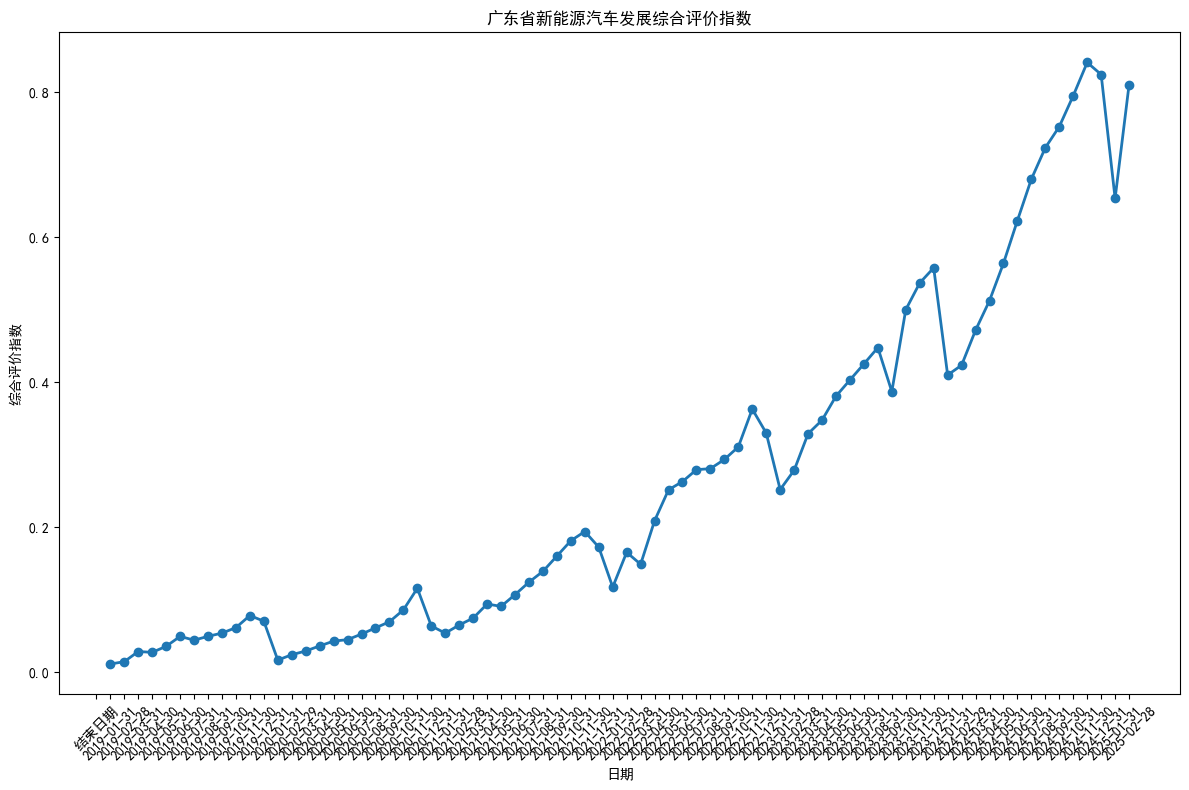

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = 'processed_data.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 查看列名，确保列名正确
print("列名：", df.columns.tolist())

# 文件中的实际列名
actual_columns = [
    '单位：台',
    '单位：万千瓦时',
    '单位：GWh',
    '单位：辆',
    '单位：辆.1',
    '单位：辆.2',
    '单位：辆.3'
]

# 代码中定义的列名
defined_columns = [
    '单位：台: 公共充电桩数量',
    '单位：万千瓦时: 公共充电桩充电电量',
    '单位：GWh: 电池装机量',
    '单位：辆: 燃料电池产量',
    '单位：辆.1: 新能源汽车产量',
    '单位：辆.2: 燃料电池销量',
    '单位：辆.3: 新能源汽车销量'
]

# 创建列名映射
column_mapping = dict(zip(actual_columns, defined_columns))

# 重命名列
df.rename(columns=column_mapping, inplace=True)

# 提取需要处理的列
columns = defined_columns

# 确保只对数值列进行操作
numeric_df = df[columns].apply(pd.to_numeric, errors='coerce')

# 数据标准化（Min-Max归一化）
for column in columns:
    if column in numeric_df.columns:
        min_val = numeric_df[column].min()
        max_val = numeric_df[column].max()
        df[column + '_normalized'] = (numeric_df[column] - min_val) / (max_val - min_val)
    else:
        print(f"列 '{column}' 不是数值列。")

# 假设的AHP权重（根据专家判断或经验设定）
ahp_weights = {
    '单位：台: 公共充电桩数量': 0.15,
    '单位：万千瓦时: 公共充电桩充电电量': 0.10,
    '单位：GWh: 电池装机量': 0.10,
    '单位：辆: 燃料电池产量': 0.05,
    '单位：辆.1: 新能源汽车产量': 0.25,
    '单位：辆.2: 燃料电池销量': 0.05,
    '单位：辆.3: 新能源汽车销量': 0.35
}

# 熵值法计算客观权重
def calculate_entropy_weights(data):
    # 避免除以零或负数
    data = np.where(data <= 0, 1e-10, data)
    # 计算熵值
    entropy = -data * np.log(data)
    entropy = np.nansum(entropy, axis=0)
    # 计算差异系数
    diff_coeff = 1 - entropy / np.log(len(data))
    # 计算客观权重
    weights = diff_coeff / np.sum(diff_coeff)
    return weights

# 提取归一化后的数据
normalized_columns = [col + '_normalized' for col in columns]
normalized_data = df[normalized_columns].values

# 计算熵值法权重
entropy_weights = calculate_entropy_weights(normalized_data)

# 设置权重分配系数α
alpha_values = {
    '单位：台: 公共充电桩数量': 0.165,
    '单位：万千瓦时: 公共充电桩充电电量': 0.115,
    '单位：GWh: 电池装机量': 0.11,
    '单位：辆: 燃料电池产量': 0.055,
    '单位：辆.1: 新能源汽车产量': 0.275,
    '单位：辆.2: 燃料电池销量': 0.061,
    '单位：辆.3: 新能源汽车销量': 0.318
}

# 计算综合权重
combined_weights = []
for i, column in enumerate(columns):
    ahp_weight = ahp_weights[column]
    ent_weight = entropy_weights[i]
    combined_weight = alpha_values[column] * ent_weight + (1 - alpha_values[column]) * ahp_weight
    combined_weights.append(combined_weight)

# 计算广东省新能源汽车发展的综合评价指数
comprehensive_index = np.sum(normalized_data * combined_weights, axis=1)

# 将指数添加到数据框
df['综合评价指数'] = comprehensive_index

# 保存结果到新的Excel文件
output_file_path = 'comprehensive_index.xlsx'
df.to_excel(output_file_path, index=False)

print(f"综合评价指数已计算并保存到 {output_file_path}")

# 可视化综合评价指数
plt.figure(figsize=(12, 8))
plt.plot(df['Unnamed: 0'], df['综合评价指数'], marker='o', linestyle='-', linewidth=2)
plt.title('广东省新能源汽车发展综合评价指数')
plt.xlabel('日期')
plt.ylabel('综合评价指数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

列名： ['Unnamed: 0', '单位：台', '单位：万千瓦时', '单位：GWh', '单位：辆', '单位：辆.1', '单位：辆.2', '单位：辆.3']
新能源汽车指数已计算并保存到 new_energy_vehicle_index.xlsx


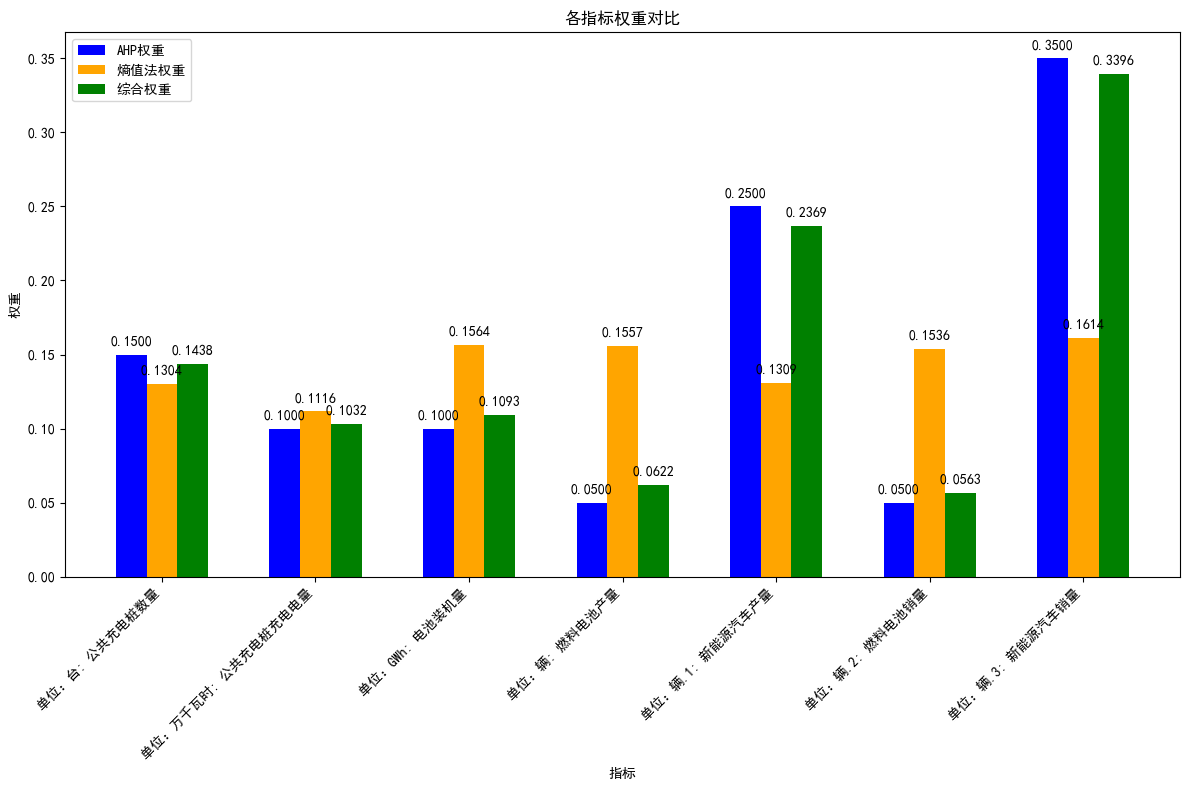

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = 'processed_data.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 查看列名，确保列名正确
print("列名：", df.columns.tolist())

# 文件中的实际列名
actual_columns = [
    '单位：台',
    '单位：万千瓦时',
    '单位：GWh',
    '单位：辆',
    '单位：辆.1',
    '单位：辆.2',
    '单位：辆.3'
]

# 代码中定义的列名
defined_columns = [
    '单位：台: 公共充电桩数量',
    '单位：万千瓦时: 公共充电桩充电电量',
    '单位：GWh: 电池装机量',
    '单位：辆: 燃料电池产量',
    '单位：辆.1: 新能源汽车产量',
    '单位：辆.2: 燃料电池销量',
    '单位：辆.3: 新能源汽车销量'
]

# 创建列名映射
column_mapping = dict(zip(actual_columns, defined_columns))

# 重命名列
df.rename(columns=column_mapping, inplace=True)

# 提取需要处理的列
columns = defined_columns

# 确保只对数值列进行操作
numeric_df = df[columns].apply(pd.to_numeric, errors='coerce')

# 数据标准化（Min-Max归一化）
for column in columns:
    if column in numeric_df.columns:
        min_val = numeric_df[column].min()
        max_val = numeric_df[column].max()
        df[column + '_normalized'] = (numeric_df[column] - min_val) / (max_val - min_val)
    else:
        print(f"列 '{column}' 不是数值列。")

# 假设的AHP权重（根据专家判断或经验设定）
ahp_weights = {
    '单位：台: 公共充电桩数量': 0.15,
    '单位：万千瓦时: 公共充电桩充电电量': 0.10,
    '单位：GWh: 电池装机量': 0.10,
    '单位：辆: 燃料电池产量': 0.05,
    '单位：辆.1: 新能源汽车产量': 0.25,
    '单位：辆.2: 燃料电池销量': 0.05,
    '单位：辆.3: 新能源汽车销量': 0.35
}

# 熵值法计算客观权重
def calculate_entropy_weights(data):
    # 避免除以零或负数
    data = np.where(data <= 0, 1e-10, data)
    # 计算熵值
    entropy = -data * np.log(data)
    entropy = np.nansum(entropy, axis=0)
    # 计算差异系数
    diff_coeff = 1 - entropy / np.log(len(data))
    # 计算客观权重
    weights = diff_coeff / np.sum(diff_coeff)
    return weights

# 提取归一化后的数据
normalized_columns = [col + '_normalized' for col in columns]
normalized_data = df[normalized_columns].values

# 计算熵值法权重
entropy_weights = calculate_entropy_weights(normalized_data)

# 设置权重分配系数α
alpha_values = {
    '单位：台: 公共充电桩数量': 0.318,
    '单位：万千瓦时: 公共充电桩充电电量': 0.275,
    '单位：GWh: 电池装机量': 0.165,
    '单位：辆: 燃料电池产量': 0.115,
    '单位：辆.1: 新能源汽车产量': 0.11,
    '单位：辆.2: 燃料电池销量': 0.061,
    '单位：辆.3: 新能源汽车销量': 0.055
}

# 计算综合权重
combined_weights = []
for i, column in enumerate(columns):
    ahp_weight = ahp_weights[column]
    ent_weight = entropy_weights[i]
    combined_weight = alpha_values[column] * ent_weight + (1 - alpha_values[column]) * ahp_weight
    combined_weights.append(combined_weight)

# 计算新能源汽车指数
new_energy_vehicle_index = np.dot(normalized_data, combined_weights)

# 将指数添加到数据框
df['新能源汽车指数'] = new_energy_vehicle_index

# 保存结果到新的Excel文件
output_file_path = 'new_energy_vehicle_index.xlsx'
df.to_excel(output_file_path, index=False)

print(f"新能源汽车指数已计算并保存到 {output_file_path}")

# 可视化权重
weights_df = pd.DataFrame({
    '指标': columns,
    'AHP权重': [ahp_weights[col] for col in columns],
    '熵值法权重': entropy_weights,
    '综合权重': combined_weights
})

# 绘制权重对比图
fig, ax = plt.subplots(figsize=(12, 8))
width = 0.2
x = np.arange(len(weights_df['指标']))

# 绘制条形图
bars1 = ax.bar(x - width, weights_df['AHP权重'], width, label='AHP权重', color='blue')
bars2 = ax.bar(x, weights_df['熵值法权重'], width, label='熵值法权重', color='orange')
bars3 = ax.bar(x + width, weights_df['综合权重'], width, label='综合权重', color='green')

# 添加数值标签
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2., height + 0.005,
                f'{height:.4f}',
                ha='center', va='bottom')

# 设置标题和标签
ax.set_title('各指标权重对比')
ax.set_xlabel('指标')
ax.set_ylabel('权重')
ax.set_xticks(x)
ax.set_xticklabels(weights_df['指标'], rotation=45, ha='right')
ax.legend()

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

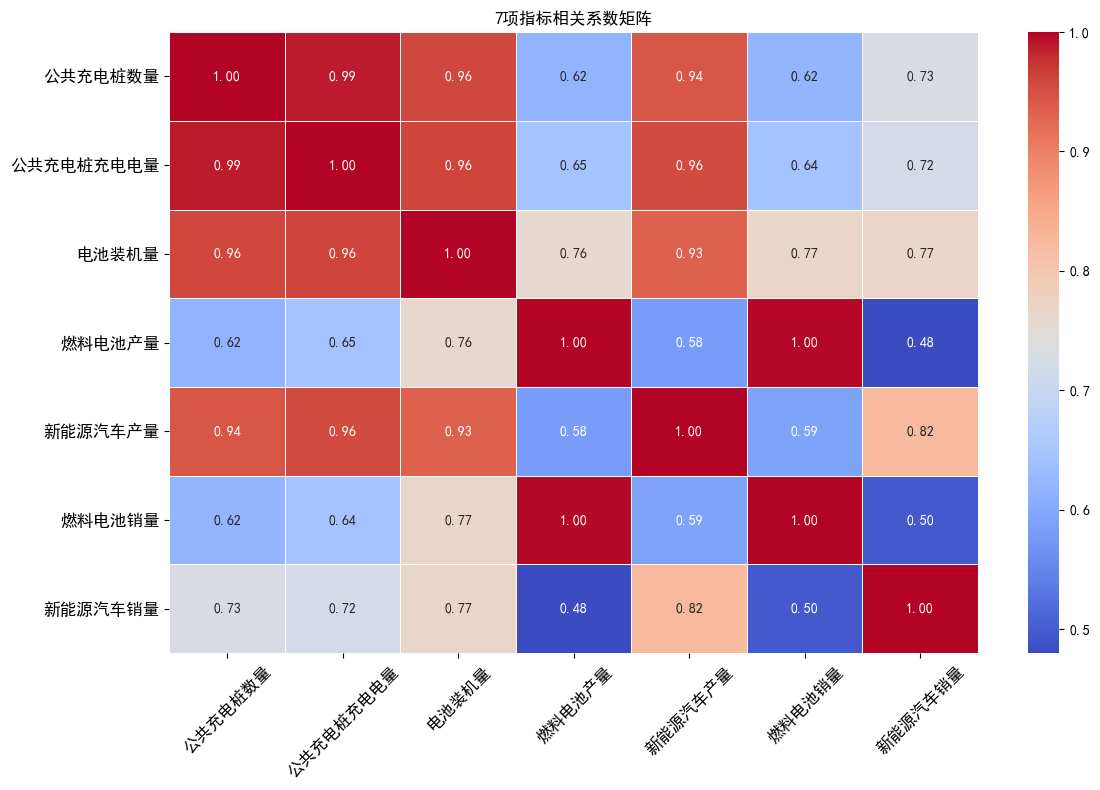

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 指定中文字体
font = FontProperties(fname=r"C:\Windows\Fonts\SimHei.ttf", size=12)

# 读取数据（假设数据已加载为DataFrame）
df = pd.read_excel('已处理数据.xls', sheet_name='行业指标数据')

# 筛选需要的7项指标列
cols = [
    '公共充电桩数量',
    '公共充电桩充电电量',
    '电池装机量',
    '燃料电池产量',
    '新能源汽车产量',
    '燃料电池销量',
    '新能源汽车销量'
]
data = df[cols]

# 计算相关系数矩阵
corr_matrix = data.corr()

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
           annot=True, 
           fmt=".2f", 
           cmap="coolwarm",
           linewidths=0.5,
           annot_kws={"size": 10})

plt.title('7项指标相关系数矩阵', fontproperties=font)
plt.xticks(rotation=45, fontproperties=font)
plt.yticks(fontproperties=font)
plt.tight_layout()
plt.show()

原始列名： ['公共充电桩数量', '公共充电桩充电电量']
重命名后的列名： ['公共充电桩数量', '公共充电桩充电电量']
文件保存成功！


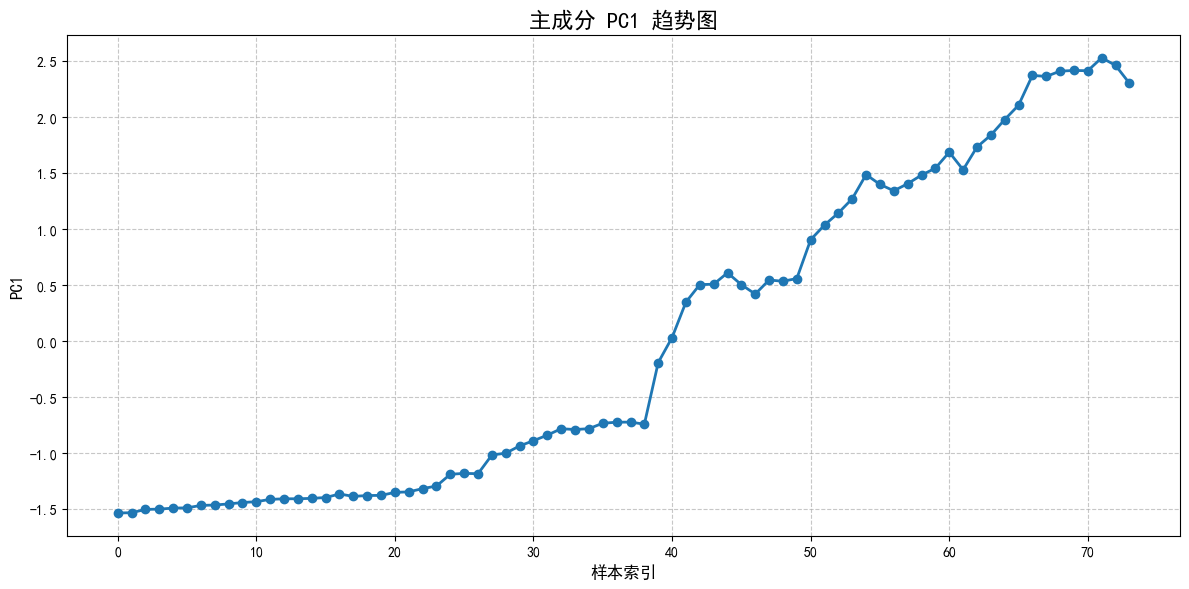

PC1 解释的方差比例: 0.9942


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 设置 Matplotlib 字体为支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取 Excel 文件
file_path = 'PCA.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 检查列名
print("原始列名：", df.columns.tolist())

# 重命名列名（如果需要）
df.columns = ['公共充电桩数量', '公共充电桩充电电量']

# 检查列名是否正确
print("重命名后的列名：", df.columns.tolist())

# 选择需要进行 PCA 的变量
variables = ['公共充电桩数量', '公共充电桩充电电量']
X = df[variables]

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 创建 PCA 对象，保留 1 个主成分
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

# 将 PCA 结果合并到原始 DataFrame
df['PC1'] = X_pca

# 保存处理后的数据
try:
    df.to_excel('processed_data_with_pca.xlsx', index=False)
    print("文件保存成功！")
except PermissionError:
    print("无法保存文件，请确保文件未被其他程序占用，并且您有权限写入该目录。")
    # 尝试保存到当前工作目录
    try:
        df.to_excel('processed_data_with_pca.xlsx', index=False)
        print("文件已保存到当前工作目录！")
    except Exception as e:
        print(f"保存文件时出错：{e}")

# 可视化主成分
plt.figure(figsize=(12, 6))
plt.plot(range(len(df)), df['PC1'], marker='o', linestyle='-', linewidth=2)
plt.title('主成分 PC1 趋势图', fontsize=16)
plt.xlabel('样本索引', fontsize=12)
plt.ylabel('PC1', fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 输出主成分的解释方差比例
print(f"PC1 解释的方差比例: {pca.explained_variance_ratio_[0]:.4f}")